In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

print("jax", jax.__version__, "| devices:", jax.devices())

jax 0.11.2 | devices: [CpuDevice(id=0)]


In [7]:
FREQS = jnp.array([1.0, 2.0, 4.0, 8.0])
NOISE_STD = 0.02


def target_fn(x):
    """x: (n,) -> (n,)"""
    return jnp.mean(jnp.sin(2 * jnp.pi * FREQS * x[:, None]), axis=-1)

def make_data(key, n=2048, noise_std=NOISE_STD):
    """Returns X: (n, 1), Y: (n, 1)"""
    key_x, key_noise = jax.random.split(key)
    x = jax.random.uniform(key_x, (n,), minval=0.0, maxval=1.0)
    y = target_fn(x) + noise_std * jax.random.normal(key_noise, (n,))
    return x[:, None], y[:, None]


X, Y = make_data(jax.random.key(0))

print(f"target variance : {float(Y.var()):.4f}")
print(Y.shape)

target variance : 0.1236
(2048, 1)


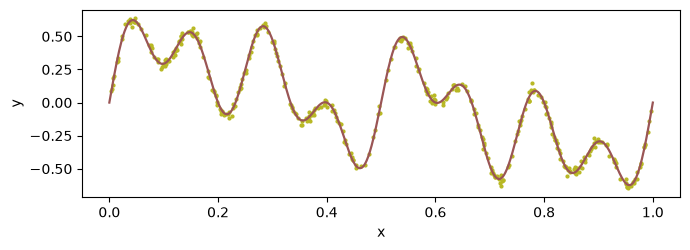

In [6]:
grid = jnp.linspace(0, 1, 1000)
plt.figure(figsize=(7, 2.6))
plt.scatter(np.array(X[:400, 0]), np.array(Y[:400, 0]), s=4, color="#b8b824")
plt.plot(np.array(grid), np.array(target_fn(grid)), color="#9a5555", lw=1.6)
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()

# Building the network

I sketched out what an MLP would look like by hand.

### The network worked out by hand for `[1, 2, 2, 1]`

**Layer 1 (input → hidden 1):**
$$
a^1_0 = \sigma\!\left(w^1_{00}\, a^0_0 + b^1_0\right), \qquad
a^1_1 = \sigma\!\left(w^1_{01}\, a^0_0 + b^1_1\right)
$$

**Layer 2 (hidden 1 → hidden 2):**
$$
a^2_0 = \sigma\!\left(w^2_{00}\, a^1_0 + w^2_{10}\, a^1_1 + b^2_0\right), \qquad
a^2_1 = \sigma\!\left(w^2_{01}\, a^1_0 + w^2_{11}\, a^1_1 + b^2_1\right)
$$

**Layer 3 (hidden 2 → output, no nonlinearity):**
$$
a^3_0 = w^3_{00}\, a^2_0 + w^3_{10}\, a^2_1 + b^3
$$

**In matrix form**, with weight $w^l_{ij}$ read as "from source unit $i$ to destination unit $j$":

$$
W^1 = \begin{pmatrix} w^1_{00} \\ w^1_{01} \end{pmatrix}, \quad
W^2 = \begin{pmatrix} w^2_{00} & w^2_{10} \\ w^2_{01} & w^2_{11} \end{pmatrix}, \quad
W^3 = \begin{pmatrix} w^3_{00} & w^3_{10} \end{pmatrix}
$$

so that each layer is just

$$
a^l = \sigma\!\left(W^l a^{l-1} + b^l\right)
$$

with $W^l$ shaped $(n_l, n_{l-1})$ — rows are destination units, columns are source units — and $\sigma$ applied elementwise (identity on the output layer).

$$
\Theta = \left(\,[W^1, b^1],\ [W^2, b^2],\ [W^3, b^3]\,\right)
$$

In [ ]:
def init_mlp(key, layer_sizes):
    keys = jax.random.split(key,len(layer_sizes) - 1) # one subkey per layer
    m1 = layer_sizes[1]
    m2 = layer_sizes[2]

    # initialize biases as zeros
    b1 = jnp.zeros(m1)
    b2 = jnp.zeros(m2)
    b3 = jnp.zeros(1)

    # initialize weights randomly
    # std normalization for weights keeps variance low
    # called He initialization
    std1 = jnp.sqrt(2 / 1)
    w1 = jax.random.normal(0,(m1, 1)) * std1
    std2 = jnp.sqrt(2 / m1)
    w2 = jax.random.normal(1,(m2, m1)) * std2
    std3 = jnp.sqrt(2 / m2)
    w3 = jax.random.normal(2,(1, m2)) * std3

    theta1 = [w1,b1]
    theta2 = [w2,b2]
    theta3 = [w3,b3]
    params = [theta1,theta2,theta3]
    return params

def relu(z):
    a = jnp.clip(z,0,None)
    return a

def forward(params, x):
    """Runs the MLP forward for an input x = (1,)"""
    #first hidden layer
    w1 = params[0][0]
    b1 = params[0][1]
    # assume for now x is a single number
    z1 = w1 @ x + b1
    a1 = relu(z1)

    #second hidden layer
    w2 = params[1][0]
    b2 = params[1][1]
    z2 = w2 @ a1 + b2
    a2 = relu(z2)

    #output layer
    w3 = params[2][0]
    b3 = params[2][1]
    z3 = w3 @ a2 + b3
    return z3

def forward_batch(params,X):
    """Run forward on a batch of input data size X=(N,1)"""
    #don't map over arg 0 (params), map axis 0 of arg 1 (X)
    batched_forward = jax.vmap(forward,in_axes= (None,0)) 
    return batched_forward(params,X)
    # or:
    # Z3 = [forward(params,X[0][i]) for i in range(N)]
    # or even safer way:
    # z3 = jnp.zeros(N)
    # for i in range(N): z3[i] = forward(params,X[0][i])

def loss_fn(params, X, Y):
    return jnp.mean((forward_batch(params,X) - Y)**2)

In [ ]:
# initiate MLP
init_mlp(jax.random.key(0),[1,128,128,1])